# Description
Analyze data in water year 2025-2026. Data was downloaded on April 23, 2026.

# Load analysis functions

In [1]:
%run ....../imports.ipynb
%run ....../snotelAnalysisFunctions.ipynb

# Plotting functions

In [2]:
def mapPlotFunction(ax,data,lons,lats,cmap,bounds,plotTitle):
    '''
    ax should result from the call of ax1 = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
    data is used to color the station scatter points
    bounds is an np array that specifies the colorbar levels
    plotTitle is a string
    '''
    
    # Add coastlines
    ax.coastlines(linewidth=0.5,zorder=-1)
    
    # Add U.S. state borders
    ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    gl.xlines = False
    gl.ylines = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.left_labels = False
    gl.ylocator = mticker.FixedLocator(np.arange(32,54,4))
    gl.xlabel_style = {'size': 7, 'color': 'k', 'va':'top'}
    gl.ylabel_style = {'size': 7, 'color': 'k', 'ha':'right'}
    
    scatterSize = 20
    
    # define the bins and normalize
    norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
    
    sc = ax.scatter(lons,lats,scatterSize,
                     c=data,cmap=cmap,edgecolor='k',linewidth=.5,zorder=0,norm=norm)
    
    # Alaska stations #
    axins = ax.inset_axes(bounds = [-.14,0.025,0.6,.6],projection=ccrs.Mercator())
    axins.scatter(lons,lats,scatterSize,
                  c=data,cmap=cmap,edgecolor='k',linewidth=.5,transform=ccrs.PlateCarree(),zorder=0,norm=norm)
    axins.coastlines(linewidth=0.5,zorder=-1)
    axins.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
    lon1, lon2, lat1, lat2 = -165, -128, 53, 72
    axins.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    gl = axins.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    gl.xlines = False
    gl.ylines = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.bottom_labels = False
    gl.left_labels = False
    gl.ylocator = mticker.FixedLocator(np.arange(55,75,5))
    gl.xlabel_style = {'size': 5, 'color': 'k', 'va':'top'}
    gl.ylabel_style = {'size': 5, 'color': 'k', 'ha':'right'}
    
    
    # add colorbar
    cbaxes = inset_axes(ax,
        width="27%",  # width: 50% of parent_bbox width
        height="5%",  # height: 5%
        loc="upper left",
    )
    cbaxes.xaxis.set_ticks_position("bottom")
    cbar = fig.colorbar(sc,cax=cbaxes,label=r'[%]',
                orientation='horizontal')
    cbar.ax.tick_params(labelsize=7)
    
    ax.set_title(plotTitle,fontsize=12)
    
    lon1, lon2, lat1, lat2 = -138, -101.5, 31, 50
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())

In [3]:
# Source - https://stackoverflow.com/a/20528097
# Posted by Paul H, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-27, License - CC BY-SA 4.0


def shiftedColorMap(cmap, start=0, midpoint=0.5, stop=1.0, name='shiftedcmap'):
    '''
    Function to offset the "center" of a colormap. Useful for
    data with a negative min and positive max and you want the
    middle of the colormap's dynamic range to be at zero.

    Input
    -----
      cmap : The matplotlib colormap to be altered
      start : Offset from lowest point in the colormap's range.
          Defaults to 0.0 (no lower offset). Should be between
          0.0 and `midpoint`.
      midpoint : The new center of the colormap. Defaults to 
          0.5 (no shift). Should be between 0.0 and 1.0. In
          general, this should be  1 - vmax / (vmax + abs(vmin))
          For example if your data range from -15.0 to +5.0 and
          you want the center of the colormap at 0.0, `midpoint`
          should be set to  1 - 5/(5 + 15)) or 0.75
      stop : Offset from highest point in the colormap's range.
          Defaults to 1.0 (no upper offset). Should be between
          `midpoint` and 1.0.
    '''
    cmap = getattr(plt.cm,cmap)
    
    cdict = {
        'red': [],
        'green': [],
        'blue': [],
        'alpha': []
    }

    # regular index to compute the colors
    reg_index = np.linspace(start, stop, 257)

    # shifted index to match the data
    shift_index = np.hstack([
        np.linspace(0.0, midpoint, 128, endpoint=False), 
        np.linspace(midpoint, 1.0, 129, endpoint=True)
    ])

    for ri, si in zip(reg_index, shift_index):
        r, g, b, a = cmap(ri)

        cdict['red'].append((si, r, r))
        cdict['green'].append((si, g, g))
        cdict['blue'].append((si, b, b))
        cdict['alpha'].append((si, a, a))

    newcmap = matplotlib.colors.LinearSegmentedColormap(name, cdict)
    #plt.register_cmap(cmap=newcmap)

    return newcmap


# Load data

add choice for loading all stations or just biased corrected stations...

In [4]:
stationBiasDict = loadTempBiasMarker()

In [5]:
rootPath = '/nfs/twcroninlab002/nicknish/snowpackProject/snotelData/raw/'
stateNames = ['CO','AK','AZ','CA','ID','MT','NM','NV','OR','SD','UT','WA','WY']
metaData = loadStationMetaData()

In [6]:
allStateDict = {}
for stateName in tqdm(stateNames):
    stateFileNames = glob.glob(rootPath + stateName + '/' + '*')
    stateDataAll = [csvToXarray(f) for f in stateFileNames]
    stateDataCleaned = [s for s in stateDataAll if s.BAD_DATA==False]
    allStateDict[stateName] = stateDataCleaned

100%|███████████████████████████████████████████| 13/13 [00:25<00:00,  1.98s/it]


In [7]:
## Filter stations with the same functions used in other notebooks ##
allStateDict_filtered = filterStations(stateNames,allStateDict)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 88/89         

In [8]:
allStationNames = []
for stateName in tqdm(stateNames):
    currStateData = allStateDict_filtered[stateName]
    for iS,currStation in (enumerate(currStateData)):
        allStationNames = allStationNames + [currStation.name]

100%|██████████████████████████████████████████| 13/13 [00:00<00:00, 687.32it/s]


In [9]:
allStateDict_prcpRate_tauF = winterPrcpRateByYear(stateNames,allStateDict_filtered,accumThresh = 0)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM']: 3/27         

/tmp/ipykernel_170349/132286664.py:58: RuntimeWarning: invalid value encountered in scalar divide
  P_duringSnow = np.sum(currPInterp[firstSnowInd:indMax])/tMax_tStart_days


['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

In [10]:
allStateDict_Tw = obsMeanWinterTemp(stateNames,allStateDict_filtered)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

## Load 2025-2026 data

In [11]:
rootPath = '/nfs/twcroninlab002/nicknish/snowpackProject/snotelData/raw/2025-2026/'

In [12]:
allStateDict_2526 = {}
for stateName in tqdm(stateNames):
    stateFileNames = glob.glob(rootPath + stateName + '/' + '*')
    stateDataAll = [csvToXarray(f,True) for f in stateFileNames]
    stateDataCleaned = [s for s in stateDataAll if s.BAD_DATA==False]
    allStateDict_2526[stateName] = stateDataCleaned

100%|███████████████████████████████████████████| 13/13 [00:10<00:00,  1.25it/s]


In [13]:
# Certain stations have bad data in 2025-2026, filter them out here
for iState,stateName in enumerate(stateNames):        
    currStateData = allStateDict_2526[stateName]
    currStateDataNew = [] # list of modified stations
    for iS,currStation in (enumerate(currStateData)):
        print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
        if currStation.number not in [522,1182]: # Hickerson Park, UT; Bettles Field, AK (winter not over)
            currStateDataNew = currStateDataNew + [currStation]
    allStateDict_2526[stateName] = currStateDataNew

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 88/89         

# Calculate climatological SWE and T seasonal cycles

In [14]:
climSWE_T_DICT = {}  
for iState,stateName in enumerate(stateNames):        
    currStateData = allStateDict_filtered[stateName]
    currStateDataNew = [] # list of modified stations
    for iS,currStation in (enumerate(currStateData)):
        print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
        climSWECycle = currStation.swe.groupby(currStation.time.dt.dayofyear).mean()
        climSWEMinCycle = currStation.swe.groupby(currStation.time.dt.dayofyear).min()
        climSWEMaxCycle = currStation.swe.groupby(currStation.time.dt.dayofyear).max()
        climSWECycle['sweMin'] = climSWEMinCycle
        climSWECycle['sweMax'] = climSWEMaxCycle
        climTCycle = currStation.T_avg.groupby(currStation.time.dt.dayofyear).mean()
        climSWECycle['temp'] = climTCycle
        climSWECycle = climSWECycle.assign_attrs(number=currStation.number)
        currStateDataNew = currStateDataNew + [climSWECycle]
    climSWE_T_DICT[stateName] = currStateDataNew

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

# Apply analytical model to WY 2025-2026

In [15]:
for iState,stateName in enumerate(stateNames):   
    currStateData = allStateDict_2526[stateName]
    newStateData = []
    for iS,currStation in (enumerate(currStateData)):
        print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
        if currStation.name in allStationNames:
            currStationWYs = np.unique(currStation.water_year.values)
            for WY in currStationWYs:
                currWY = currStation.sel(time=(currStation.water_year == WY))
                currSWE = currWY.swe
                currT = currWY.T_avg
                currP = currWY.prcp
                if np.isnan(currT).all() or sum(np.isnan(currSWE.values))>15 or sum(np.isnan(currT.values))>15 or sum(np.isnan(currP.values))>15:
                    pass
                else:
                    currTime = currWY.time               
                    novThruMarInds = np.logical_or(currTime.dt.month >= 11,currTime.dt.month <= 3)              
                    currTInterp = fillNANTemp(currT.values)
                    currPInterp = fillNANPrcp(currP.values)  
                    
                    Pw2526 = np.nanmean(currPInterp[novThruMarInds])
                    tauF2526 = np.sum(currTInterp<=0)
                    SWEmax2526 = np.max(currSWE)
                    
                    newStateData = newStateData + [currStation.assign_attrs(Pw=Pw2526,tauF=tauF2526,SWEmax=SWEmax2526)]
    allStateDict_2526[stateName] = newStateData

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 88/89         

# Maps


In [16]:
## Calculate percent decrease in tau_F and P_w compared to climatology ##

tauFClimArray = np.array([])
tauF2526Array = np.array([])
TwClimArray = np.array([])
Tw2526Array = np.array([])
PwClimArray = np.array([])
Pw2526Array = np.array([])
SWEmaxClimArray = np.array([])
SWEmax2526Array = np.array([])

stationNumbers = np.array([])
stationStates = np.array([])
lats = np.array([])
lons = np.array([])

for istate,stateName in tqdm(enumerate(stateNames)):
    stations = allStateDict_prcpRate_tauF[stateName]
    if len(stations)>0:
        for stat in stations:
            if stat.number!=604: # no data available for this station in 25-26
                # calculate data for 2025-2026
                station2526 = stationLookupByNumber(stat.number,allStateDict_2526)
                if station2526 != False:
                    currSWE = station2526.swe
                    currT = station2526.T_avg
                    if np.isnan(currT).all():
                        pass
                    else:
                        currP = station2526.prcp
                        currTime = station2526.time               
                        novThruMarInds = np.logical_or(currTime.dt.month >= 11,currTime.dt.month <= 3)              
                        currTInterp = fillNANTemp(currT.values)
                        currPInterp = fillNANPrcp(currP.values)  
                        
                        Pw = np.nanmean(currPInterp[novThruMarInds])
                        Tw = np.nanmean(currTInterp[novThruMarInds])
                        tauF = np.sum(currTInterp<=0)
                        SWEmax = np.max(currSWE)
        
                        tauF2526Array = np.append(tauF2526Array,tauF)
                        Pw2526Array = np.append(Pw2526Array,Pw)
                        Tw2526Array = np.append(Tw2526Array,Tw)
                        SWEmax2526Array = np.append(SWEmax2526Array,SWEmax)
                        
                        # Calculate station climatological mean values
                        currStatMeanTauF = np.mean(stat.numDaysBelowTThresh_s)
                        currStatMeanPw = np.mean(stat.precipRates)
                        currStatMeanSWEMax = np.mean(stat.peakSWE)
                        tauFClimArray = np.append(tauFClimArray,currStatMeanTauF)
                        PwClimArray = np.append(PwClimArray,currStatMeanPw)
                        TwClimArray = np.append(TwClimArray,stationLookupByNumber(stat.number,allStateDict_Tw).meanWinterTemp)
                        SWEmaxClimArray = np.append(SWEmaxClimArray,currStatMeanSWEMax)
        
                        # Collect meta data
                        stationNumbers = np.append(stationNumbers,station2526.number)
                        stationStates = np.append(stationStates,stateName)
                        lats = np.append(lats,stat.latitude)
                        lons = np.append(lons,stat.longitude)

0it [00:00, ?it/s]

Number not found!


1it [00:00,  1.38it/s]

Number not found!
Number not found!
Number not found!
Number not found!
Number not found!
Number not found!
Number not found!
Number not found!


4it [00:01,  2.54it/s]

...

11it [00:07,  1.11it/s]

Number not found!
Number not found!


12it [00:08,  1.19it/s]

Number not found!


13it [00:09,  1.31it/s]


In [17]:
tauFPercentAnom = (tauF2526Array-tauFClimArray)/tauFClimArray * 100
PwPercentAnom = (Pw2526Array-PwClimArray)/PwClimArray * 100
sweMaxPercentAnom = (SWEmax2526Array-SWEmaxClimArray)/SWEmaxClimArray * 100
sweMaxPercentOfNormal = SWEmax2526Array/SWEmaxClimArray * 100
TwAnom = Tw2526Array - TwClimArray

# Main WY26 Figure

In [20]:
# create indices for shifting data to start on Oct 1
daysToAnalyze = np.arange(1,367)
dates = np.array([datetime.datetime(2000, 1, 1) + datetime.timedelta(int(d) - 1) for d in daysToAnalyze])
months = np.array([d.month for d in dates])
waterYearInds = np.append(np.nonzero(months>=10)[0],np.nonzero(months<10)[0])
waterYearInds = waterYearInds[waterYearInds<365]

In [21]:
stationNumber = 709

In [22]:
## Generate climatology for plot ##
stationClimSWE = stationLookupByNumber(stationNumber,climSWE_T_DICT)

climTime = np.arange(365)#stationClimSWE.dayofyear.values[waterYearInds]
climSWECycle = stationClimSWE.values[waterYearInds]
sweMaxCycle = stationClimSWE.sweMax.values[waterYearInds]
sweMinCycle = stationClimSWE.sweMin.values[waterYearInds]
climPw = PwClimArray[stationNumbers==stationNumber]
climTauF = tauFClimArray[stationNumbers==stationNumber]
climSWECycleMaxDay = np.argmax(climSWECycle)
clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)

## And data for the specific station ##
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
wy2526SWE = chosenStation.swe.values
wy2526Time = np.arange(len(wy2526SWE))
wy2526TauFDays = np.nonzero(chosenStation.T_avg.values<0)[0]
wy2526PeakSWEDay = np.argmax(wy2526SWE)
wy2526TauF = len(wy2526TauFDays)
wy2526Pw = chosenStation.Pw
wy2526_pwDomain = np.arange(wy2526PeakSWEDay-wy2526TauF,wy2526PeakSWEDay)

/tmp/ipykernel_170349/2102875510.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)


In [23]:
len(stationNumbers)

484

In [24]:
# determine stations with record low years
count = 0
stationRecord = []
stationNoRecord = []
wy26PercentRecord = []
wy26PercentNoRecord = []
recordLons = []
recordLats = []
noRecordLons = []
noRecordLats = []
for stationNumber in stationNumbers:
    previousMin = stationLookupByNumber(stationNumber,climSWE_T_DICT).sweMin
    previousMinMax = previousMin.max().values
    wy26SWEMax = stationLookupByNumber(stationNumber,allStateDict_2526).swe.max().values
    if wy26SWEMax<previousMinMax:
        count = count + 1
        stationRecord = np.append(stationRecord,stationNumber)
        recordLats = np.append(recordLats,lats[stationNumbers==stationNumber])
        recordLons = np.append(recordLons,lons[stationNumbers==stationNumber])
        wy26PercentRecord = np.append(wy26PercentRecord,sweMaxPercentOfNormal[stationNumbers==stationNumber])
    else:
        stationNoRecord = np.append(stationNoRecord,stationNumber)
        noRecordLats = np.append(noRecordLats,lats[stationNumbers==stationNumber])
        noRecordLons = np.append(noRecordLons,lons[stationNumbers==stationNumber])
        wy26PercentNoRecord = np.append(wy26PercentNoRecord,sweMaxPercentOfNormal[stationNumbers==stationNumber])

/tmp/ipykernel_170349/1217317969.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


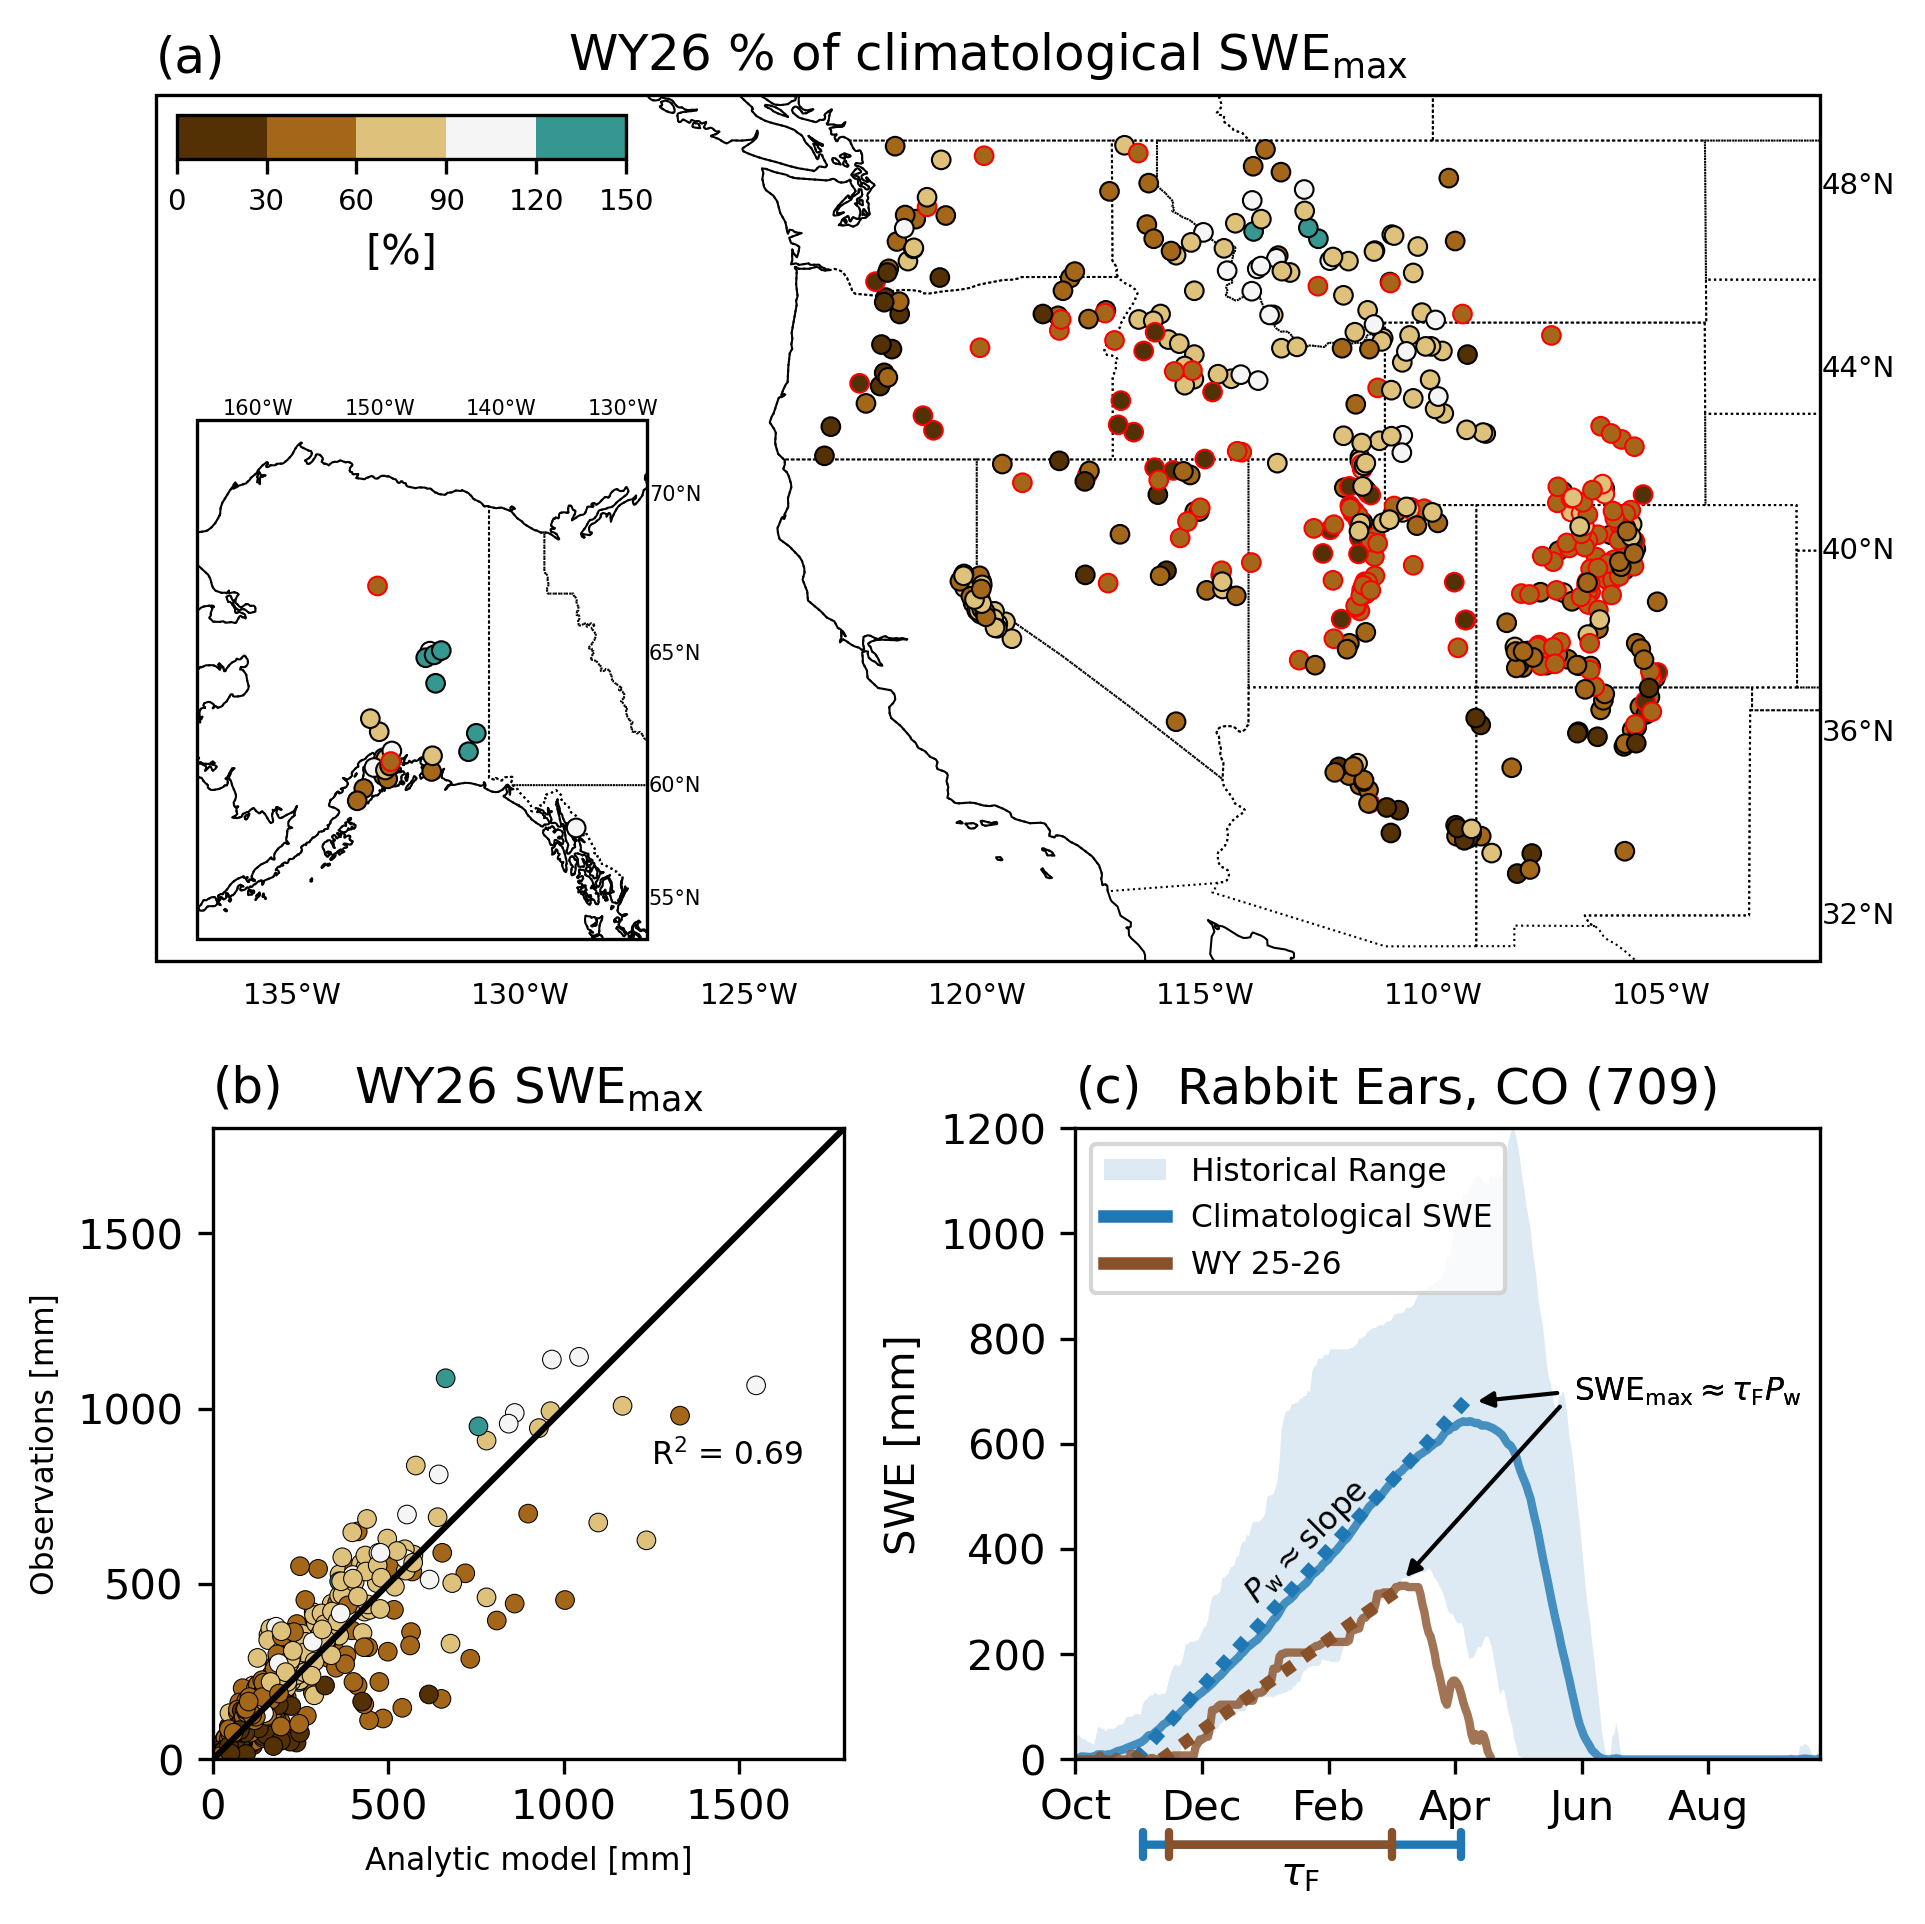

In [25]:
fig = plt.figure(figsize=(6.5,6.5),dpi=300)
gs = GridSpec(2,2,width_ratios=[1,1],height_ratios=[1,.7])
annoFontSize = 7.5

########################################
  ########## Map ###############
########################################

# Continental US Stations #
ax = fig.add_subplot(gs[0,:], projection=ccrs.PlateCarree())


# Add coastlines
ax.coastlines(linewidth=0.5,zorder=-1)

# Add U.S. state borders
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
gl.left_labels = False
gl.ylocator = mticker.FixedLocator(np.arange(32,54,4))
gl.xlabel_style = {'size': 7, 'color': 'k', 'va':'top'}
gl.ylabel_style = {'size': 7, 'color': 'k', 'ha':'right'}

scatterSize = 20
    
# define the bins and normalize
cmap = shiftedColorMap('BrBG',midpoint=2/3,stop=0.8)
bounds = np.arange(0,170,30)
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)

# plot some of the non-record breaking stations
shuffle1 = np.arange(len(wy26PercentNoRecord))
np.random.shuffle(shuffle1)
shuffled1 = wy26PercentNoRecord[shuffle1]
shuffled1Lats = noRecordLats[shuffle1]
shuffled1Lons = noRecordLons[shuffle1]
sc = ax.scatter(shuffled1Lons[:200],shuffled1Lats[:200],scatterSize,
                 c=shuffled1[:200],cmap=cmap,edgecolor='k',linewidth=.5,zorder=0,norm=norm)

# Plot record breaking stations
sc = ax.scatter(recordLons,recordLats,20,
                c=wy26PercentRecord,edgecolor='r',linewidth=.5,zorder=0,norm=norm,cmap = cmap)

# plot the rest of the stations
sc = ax.scatter(shuffled1Lons[200:],shuffled1Lats[200:],20,
                 c=shuffled1[200:],edgecolor='k',linewidth=.5,zorder=0,norm=norm,cmap = cmap)
    
#### Alaska stations ####
axins = ax.inset_axes(bounds = [-.14,0.025,0.6,.6],projection=ccrs.Mercator())
axins.scatter(noRecordLons,noRecordLats,scatterSize,
              c=wy26PercentNoRecord,cmap=cmap,edgecolor='k',linewidth=.5,transform=ccrs.PlateCarree(),zorder=0,norm=norm)
axins.scatter(recordLons,recordLats,20,
                c=wy26PercentRecord,edgecolor='r',linewidth=.5,transform=ccrs.PlateCarree(),zorder=0,norm=norm,cmap = cmap)
axins.coastlines(linewidth=0.5,zorder=-1)
axins.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
lon1, lon2, lat1, lat2 = -165, -128, 53, 72
axins.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
gl = axins.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.bottom_labels = False
gl.left_labels = False
gl.ylocator = mticker.FixedLocator(np.arange(55,75,5))
gl.xlabel_style = {'size': 5, 'color': 'k', 'va':'top'}
gl.ylabel_style = {'size': 5, 'color': 'k', 'ha':'right'}


# add colorbar
cbaxes = inset_axes(ax,
    width="27%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="upper left",
)
cbaxes.xaxis.set_ticks_position("bottom")
cbar = fig.colorbar(sc,cax=cbaxes,label=r'[%]',
            orientation='horizontal')
cbar.ax.tick_params(labelsize=7)

ax.set_title(r'WY26 % of climatological SWE$_\text{max}$',fontsize=12)

lon1, lon2, lat1, lat2 = -138, -101.5, 31, 50
ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())

ax.text(-138,50.5,'(a)',fontsize=12)


########################################
  ########## R^2 plot ###############
########################################
panelFontSize = 7.5
ax1 = fig.add_subplot(gs[1,0])

ax1.scatter(tauF2526Array*Pw2526Array,SWEmax2526Array,20,c=sweMaxPercentOfNormal,
            edgecolor='k',linewidth=.25,cmap=cmap,norm=norm)
ax1.plot(np.arange(0,1800),np.arange(0,1800),c='k',label='1-1 line')

ax1.set_xlim([0,2100])
ax1.set_ylim([0,2100])

thisR2 = round(R2_from1to1(tauF2526Array*Pw2526Array,SWEmax2526Array),2)
ax1.text(1250,840,fr'R$^2$ = {thisR2}',fontsize=panelFontSize)

ax1.set_ylabel('Observations [mm]',fontsize=panelFontSize)
ax1.set_xlabel('Analytic model [mm]',fontsize=panelFontSize)
ax1.axis('square')
ax1.set_xlim([0,1800])
ax1.set_ylim([0,1800])
ax1.set_title(r'WY26 SWE$_\text{max}$',fontsize=12)
ax1.text(0,1875,'(b)',fontsize=12)


########################################
  ########## Station Demo ###############
########################################

#### Plot of seasonal cycle ####
ax1 = fig.add_subplot(gs[1,1])
backgroundColor = 'tab:blue'#'#808080'

ax1.fill_between(climTime,sweMinCycle,sweMaxCycle,alpha=.15,facecolor=backgroundColor,label='Historical Range')
ax1.plot(climTime,climSWECycle,linewidth=2,c=backgroundColor,alpha=.8)
ax1.plot(np.arange(0,0),np.arange(0,0),c=backgroundColor,linestyle='-',linewidth=3,label='Climatological SWE')

ax1.plot(clim_pwDomain,np.arange(len(clim_pwDomain))*climPw,c=backgroundColor,linestyle=(0, (1, 1)),linewidth=3)

center = ((climSWECycleMaxDay-climTauF)[0],0)
p1 = (climSWECycleMaxDay,0)
p2 = (climSWECycleMaxDay,max(np.arange(len(clim_pwDomain))*climPw))
#AngleAnnotation(center,p1,p2,ax=ax1,size=200,color=backgroundColor)

trans = ax1.get_xaxis_transform()
plt.annotate("", xytext=(climSWECycleMaxDay-climTauF, -.135), xy=(climSWECycleMaxDay, -.135),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=backgroundColor,linewidth=2,mutation_scale=3))


#### WY Plot 25-26 ####
brownColor = '#895129'
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
ax1.plot(wy2526Time,wy2526SWE,linewidth=2,alpha=.8,c=brownColor)
ax1.plot(np.arange(0,0),np.arange(0,0),linestyle='-',linewidth=3,label='WY 25-26',c=brownColor)

ax1.plot(wy2526_pwDomain,np.arange(len(wy2526_pwDomain))*wy2526Pw,linestyle=(0, (1, 1)),c=brownColor,linewidth=3)
trans = ax1.get_xaxis_transform()
ax1.annotate("", xytext=(wy2526PeakSWEDay-wy2526TauF, -.135), xy=(wy2526PeakSWEDay, -.135),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=brownColor,linewidth=2,mutation_scale=3,linestyle='-'))
ax1.text(100,-240,r'$\tau_\text{F}$',fontsize=annoFontSize+2)

center = (wy2526PeakSWEDay-wy2526TauF,0)
p1 = (wy2526PeakSWEDay,0)
p2 = (wy2526PeakSWEDay,max(np.arange(len(wy2526_pwDomain))*wy2526Pw))
#AngleAnnotation(center, p1, p2, ax=ax1, size=200,color=brownColor,text=r"$\theta=\tan^{-1}(P_\text{w})$",textposition="edge",
#               text_kw=dict(xytext=(-45, -20),fontsize=annoFontSize))

ax1.legend(fontsize=7.5)
ax1.set_ylim([0,1200])
ax1.set_xlim([0,365])
ax1.set_xticks(np.arange(0,359,62))
ax1.set_ylabel('SWE [mm]')
ax1.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

ann = ax1.annotate(r'$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$',
                  xy=(climSWECycleMaxDay, climTauF*climPw-10), xycoords='data',
                  xytext=(300,700), textcoords='data',
                  size=annoFontSize, va="center", ha="center",
                  #bbox=dict(boxstyle="round4", fc="w"),
                  arrowprops=dict(arrowstyle="-|>",
                                  #connectionstyle="arc3,rad=0.2",
                                  relpos=(0., .5),
                                  fc="k"))

ann = ax1.annotate(r"$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$",
                  xy=(wy2526PeakSWEDay, wy2526TauF*wy2526Pw+10), xycoords='data',
                  xytext=(300,700), textcoords='data',
                  size=annoFontSize, va="center", ha="center",
                  #bbox=dict(boxstyle="round4", fc="w"),
                  arrowprops=dict(arrowstyle="-|>",
                                  relpos=(0,.5),
                                  fc="k"))

ax1.text(80,300,r'$P_\text{w}\approx$slope',rotation=45,fontsize=annoFontSize)#90-np.atan((climTauF*climPw)/climSWECycleMaxDay)[0]*180/np.pi)

ax1.set_title('Rabbit Ears, CO (709)',fontsize=12)
ax1.text(0,1250,'(c)',fontsize=12)

plt.tight_layout()


saveFigBool = 1
if saveFigBool:
    plt.savefig(f'/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figure5_wy26.pdf')

In [ ]:
## Save data for final plot
saveBool = True
if saveBool:
    pathToSave = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
    np.savez(pathToSave + '/figure6_wy26.npz',
             wy26PercentNoRecord = wy26PercentNoRecord,
             noRecordLats = noRecordLats,
             noRecordLons = noRecordLons,
             wy26PercentRecord = wy26PercentRecord,
             recordLons = recordLons,
             recordLats = recordLats,
             allStateDict_2526 = allStateDict_2526,
             climSWE_T_DICT = climSWE_T_DICT,
             PwClimArray =PwClimArray,
             tauFClimArray = tauFClimArray,
             tauF2526Array = tauF2526Array,
             Pw2526Array = Pw2526Array,
             SWEmax2526Array = SWEmax2526Array,
             sweMaxPercentOfNormal = sweMaxPercentOfNormal,
             stationNumbers = stationNumbers,
            stationStates = stationStates)

# Supplemental Figure
% of climatological $\text{SWE}_\text{max}$ in WY 25-26

In [24]:
tauFPercentNorm = (tauF2526Array)#/tauFClimArray)
PwPercentNorm = (Pw2526Array)#/PwClimArray)
SWEMaxPercentNorm = SWEmax2526Array#/SWEmaxClimArray

In [26]:
modelDelta = (tauF2526Array-tauFClimArray)*PwClimArray + (Pw2526Array-PwClimArray)*tauFClimArray + (Pw2526Array-PwClimArray)*(tauF2526Array-tauFClimArray)

In [27]:
obsDelta = SWEmax2526Array-SWEmaxClimArray

/tmp/ipykernel_2424720/3969962058.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)
/tmp/ipykernel_2424720/3969962058.py:117: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)
/tmp/ipykernel_2424720/3969962058.py:212: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,clim

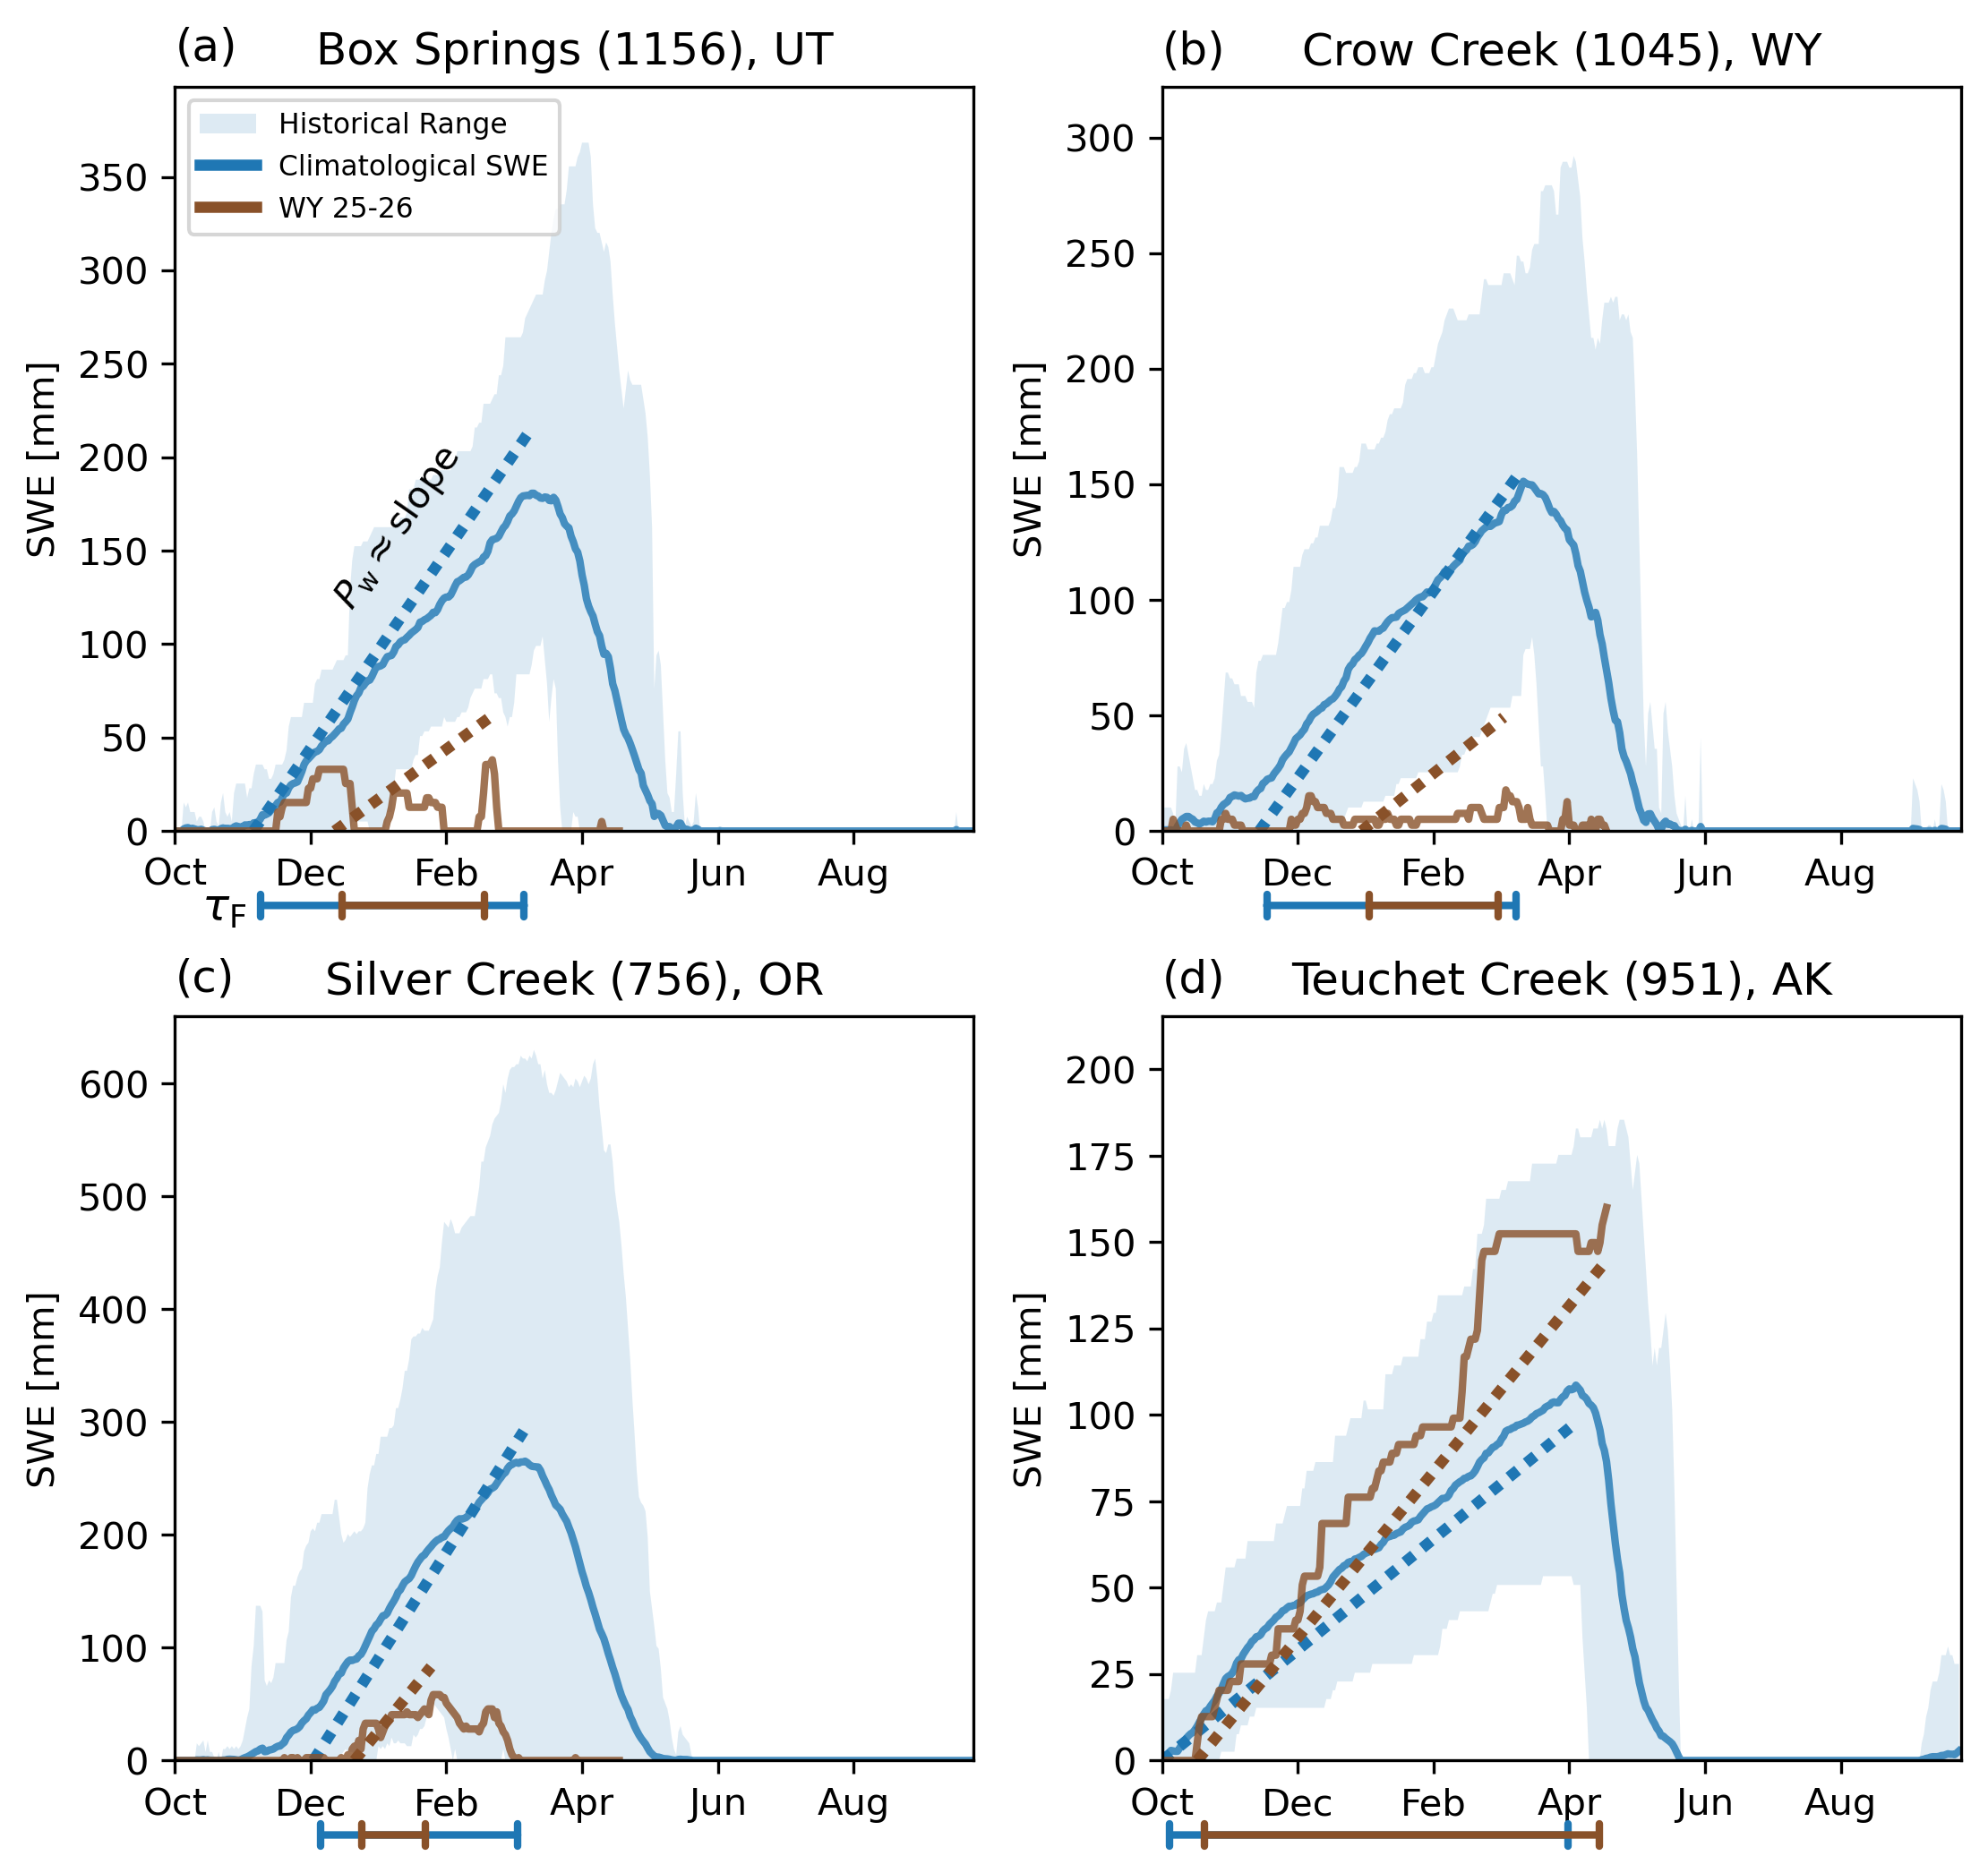

In [192]:
fig = plt.figure(figsize=(7.5,7),dpi=300)
gs = GridSpec(2,2)
annoFontSize = 10
tauFBarLevel = -.1

########################################
  ###### Station 1 Highlight ######
########################################
stationNumber = 1156
ax1 = fig.add_subplot(gs[0])

## Generate climatology for plot ##
stationClimSWE = stationLookupByNumber(stationNumber,climSWE_T_DICT)

climTime = np.arange(365)#stationClimSWE.dayofyear.values[waterYearInds]
climSWECycle = stationClimSWE.values[waterYearInds]
sweMaxCycle = stationClimSWE.sweMax.values[waterYearInds]
sweMinCycle = stationClimSWE.sweMin.values[waterYearInds]
climPw = PwClimArray[stationNumbers==stationNumber]
climTauF = tauFClimArray[stationNumbers==stationNumber]
climSWECycleMaxDay = np.argmax(climSWECycle)
clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)

## And data for the specific station ##
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
wy2526SWE = chosenStation.swe.values
wy2526Time = np.arange(len(wy2526SWE))
wy2526TauFDays = np.nonzero(chosenStation.T_avg.values<0)[0]
wy2526PeakSWEDay = np.argmax(wy2526SWE)
wy2526TauF = len(wy2526TauFDays)
wy2526Pw = chosenStation.Pw
wy2526_pwDomain = np.arange(wy2526PeakSWEDay-wy2526TauF,wy2526PeakSWEDay)

#### Plot of seasonal cycle ####
backgroundColor = 'tab:blue'#'#808080'

ax1.fill_between(climTime,sweMinCycle,sweMaxCycle,alpha=.15,facecolor=backgroundColor,label='Historical Range')
ax1.plot(climTime,climSWECycle,linewidth=2,c=backgroundColor,alpha=.8)
ax1.plot(np.arange(0,0),np.arange(0,0),c=backgroundColor,linestyle='-',linewidth=3,label='Climatological SWE')

ax1.plot(clim_pwDomain,np.arange(len(clim_pwDomain))*climPw,c=backgroundColor,linestyle=(0, (1, 1)),linewidth=3)

center = ((climSWECycleMaxDay-climTauF)[0],0)
p1 = (climSWECycleMaxDay,0)
p2 = (climSWECycleMaxDay,max(np.arange(len(clim_pwDomain))*climPw))
#AngleAnnotation(center,p1,p2,ax=ax1,size=200,color=backgroundColor)

trans = ax1.get_xaxis_transform()
plt.annotate("", xytext=(climSWECycleMaxDay-climTauF, tauFBarLevel), xy=(climSWECycleMaxDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=backgroundColor,linewidth=2,mutation_scale=3))


#### WY Plot 25-26 ####
brownColor = '#895129'
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
ax1.plot(wy2526Time,wy2526SWE,linewidth=2,alpha=.8,c=brownColor)
ax1.plot(np.arange(0,0),np.arange(0,0),linestyle='-',linewidth=3,label='WY 25-26',c=brownColor)

ax1.plot(wy2526_pwDomain,np.arange(len(wy2526_pwDomain))*wy2526Pw,linestyle=(0, (1, 1)),c=brownColor,linewidth=3)
trans = ax1.get_xaxis_transform()
ax1.annotate("", xytext=(wy2526PeakSWEDay-wy2526TauF, tauFBarLevel), xy=(wy2526PeakSWEDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=brownColor,linewidth=2,mutation_scale=3,linestyle='-'))
ax1.text(12,-48,r'$\tau_\text{F}$',fontsize=annoFontSize+2)

center = (wy2526PeakSWEDay-wy2526TauF,0)
p1 = (wy2526PeakSWEDay,0)
p2 = (wy2526PeakSWEDay,max(np.arange(len(wy2526_pwDomain))*wy2526Pw))
# AngleAnnotation(center, p1, p2, ax=ax1, size=200,color=brownColor,text=r"$\theta=\tan^{-1}(P_\text{w})$",textposition="edge",
#                text_kw=dict(xytext=(-45, -20),fontsize=annoFontSize))

ax1.legend(fontsize=7.5)
ax1.set_ylim([0,sweMaxCycle.max()+30])
ax1.set_xlim([0,365])
ax1.set_xticks(np.arange(0,359,62))
ax1.set_ylabel('SWE [mm]')
ax1.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

# ann = ax1.annotate(r'$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$',
#                   xy=(climSWECycleMaxDay, climTauF*climPw-10), xycoords='data',
#                   xytext=(300,400), textcoords='data',
#                   size=annoFontSize, va="center", ha="center",
#                   #bbox=dict(boxstyle="round4", fc="w"),
#                   arrowprops=dict(arrowstyle="-|>",
#                                   #connectionstyle="arc3,rad=0.2",
#                                   relpos=(0., .5),
#                                   fc="k"))

# ann = ax1.annotate(r"$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$",
#                   xy=(wy2526PeakSWEDay, wy2526TauF*wy2526Pw+10), xycoords='data',
#                   xytext=(300,400), textcoords='data',
#                   size=annoFontSize, va="center", ha="center",
#                   #bbox=dict(boxstyle="round4", fc="w"),
#                   arrowprops=dict(arrowstyle="-|>",
#                                   relpos=(0,.5),
#                                   fc="k"))
ax1.set_title(chosenStation.name + f', {stationStates[stationNumbers==stationNumber][0]}')

ax1.text(70,120,r'$P_\text{w}\approx$slope',rotation=55,fontsize=annoFontSize)#90-np.atan((climTauF*climPw)/climSWECycleMaxDay)[0]*180/np.pi)

ax1.text(0,sweMaxCycle.max()+44,'(a)',fontsize=12)
########################################
  ###### Station 2 Highlight ######
########################################
stationNumber = 1045
ax1 = fig.add_subplot(gs[1])

## Generate climatology for plot ##
stationClimSWE = stationLookupByNumber(stationNumber,climSWE_T_DICT)

climTime = np.arange(365)#stationClimSWE.dayofyear.values[waterYearInds]
climSWECycle = stationClimSWE.values[waterYearInds]
sweMaxCycle = stationClimSWE.sweMax.values[waterYearInds]
sweMinCycle = stationClimSWE.sweMin.values[waterYearInds]
climPw = PwClimArray[stationNumbers==stationNumber]
climTauF = tauFClimArray[stationNumbers==stationNumber]
climSWECycleMaxDay = np.argmax(climSWECycle)
clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)

## And data for the specific station ##
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
wy2526SWE = chosenStation.swe.values
wy2526Time = np.arange(len(wy2526SWE))
wy2526TauFDays = np.nonzero(chosenStation.T_avg.values<0)[0]
wy2526PeakSWEDay = np.argmax(wy2526SWE)
wy2526TauF = len(wy2526TauFDays)
wy2526Pw = chosenStation.Pw
wy2526_pwDomain = np.arange(wy2526PeakSWEDay-wy2526TauF,wy2526PeakSWEDay)

#### Plot of seasonal cycle ####
backgroundColor = 'tab:blue'#'#808080'

ax1.fill_between(climTime,sweMinCycle,sweMaxCycle,alpha=.15,facecolor=backgroundColor,label='Historical Range')
ax1.plot(climTime,climSWECycle,linewidth=2,c=backgroundColor,alpha=.8)
ax1.plot(np.arange(0,0),np.arange(0,0),c=backgroundColor,linestyle='-',linewidth=3,label='Climatological SWE')

ax1.plot(clim_pwDomain,np.arange(len(clim_pwDomain))*climPw,c=backgroundColor,linestyle=(0, (1, 1)),linewidth=3)

center = ((climSWECycleMaxDay-climTauF)[0],0)
p1 = (climSWECycleMaxDay,0)
p2 = (climSWECycleMaxDay,max(np.arange(len(clim_pwDomain))*climPw))
#AngleAnnotation(center,p1,p2,ax=ax1,size=200,color=backgroundColor)

trans = ax1.get_xaxis_transform()
plt.annotate("", xytext=(climSWECycleMaxDay-climTauF, tauFBarLevel), xy=(climSWECycleMaxDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=backgroundColor,linewidth=2,mutation_scale=3))


#### WY Plot 25-26 ####
brownColor = '#895129'
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
ax1.plot(wy2526Time,wy2526SWE,linewidth=2,alpha=.8,c=brownColor)
ax1.plot(np.arange(0,0),np.arange(0,0),linestyle='-',linewidth=3,label='WY 25-26',c=brownColor)

ax1.plot(wy2526_pwDomain,np.arange(len(wy2526_pwDomain))*wy2526Pw,linestyle=(0, (1, 1)),c=brownColor,linewidth=3)
trans = ax1.get_xaxis_transform()
ax1.annotate("", xytext=(wy2526PeakSWEDay-wy2526TauF, tauFBarLevel), xy=(wy2526PeakSWEDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=brownColor,linewidth=2,mutation_scale=3,linestyle='-'))
#ax1.text(100,-60,r'$\tau_\text{F}$',fontsize=annoFontSize+2)

center = (wy2526PeakSWEDay-wy2526TauF,0)
p1 = (wy2526PeakSWEDay,0)
p2 = (wy2526PeakSWEDay,max(np.arange(len(wy2526_pwDomain))*wy2526Pw))
# AngleAnnotation(center, p1, p2, ax=ax1, size=200,color=brownColor,text=r"$\theta=\tan^{-1}(P_\text{w})$",textposition="edge",
#                text_kw=dict(xytext=(-45, -20),fontsize=annoFontSize))

#ax1.legend(fontsize=7.5)
ax1.set_ylim([0,sweMaxCycle.max()+30])
ax1.set_xlim([0,365])
ax1.set_xticks(np.arange(0,359,62))
ax1.set_ylabel('SWE [mm]')
ax1.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

# ann = ax1.annotate(r'$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$',
#                   xy=(climSWECycleMaxDay, climTauF*climPw-10), xycoords='data',
#                   xytext=(300,400), textcoords='data',
#                   size=annoFontSize, va="center", ha="center",
#                   #bbox=dict(boxstyle="round4", fc="w"),
#                   arrowprops=dict(arrowstyle="-|>",
#                                   #connectionstyle="arc3,rad=0.2",
#                                   relpos=(0., .5),
#                                   fc="k"))

# ann = ax1.annotate(r"$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$",
#                   xy=(wy2526PeakSWEDay, wy2526TauF*wy2526Pw+10), xycoords='data',
#                   xytext=(300,400), textcoords='data',
#                   size=annoFontSize, va="center", ha="center",
#                   #bbox=dict(boxstyle="round4", fc="w"),
#                   arrowprops=dict(arrowstyle="-|>",
#                                   relpos=(0,.5),
#                                   fc="k"))
ax1.set_title(chosenStation.name + f', {stationStates[stationNumbers==stationNumber][0]}')
ax1.text(0,sweMaxCycle.max()+40,'(b)',fontsize=12)
#ax1.text(70,100,r'$P_\text{w}\approx$slope',rotation=45,fontsize=annoFontSize)#90-np.atan((climTauF*climPw)/climSWECycleMaxDay)[0]*180/np.pi)


# ########################################
#   ###### Station 3 Highlight ######
# ########################################
stationNumber = 951
ax1 = fig.add_subplot(gs[3])

## Generate climatology for plot ##
stationClimSWE = stationLookupByNumber(stationNumber,climSWE_T_DICT)

climTime = np.arange(365)#stationClimSWE.dayofyear.values[waterYearInds]
climSWECycle = stationClimSWE.values[waterYearInds]
sweMaxCycle = stationClimSWE.sweMax.values[waterYearInds]
sweMinCycle = stationClimSWE.sweMin.values[waterYearInds]
climPw = PwClimArray[stationNumbers==stationNumber]
climTauF = tauFClimArray[stationNumbers==stationNumber]
climSWECycleMaxDay = np.argmax(climSWECycle)
clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)

## And data for the specific station ##
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
wy2526SWE = chosenStation.swe.values
wy2526Time = np.arange(len(wy2526SWE))
wy2526TauFDays = np.nonzero(chosenStation.T_avg.values<0)[0]
wy2526PeakSWEDay = np.argmax(wy2526SWE)
wy2526TauF = len(wy2526TauFDays)
wy2526Pw = chosenStation.Pw
wy2526_pwDomain = np.arange(wy2526PeakSWEDay-wy2526TauF,wy2526PeakSWEDay)

#### Plot of seasonal cycle ####
backgroundColor = 'tab:blue'#'#808080'

ax1.fill_between(climTime,sweMinCycle,sweMaxCycle,alpha=.15,facecolor=backgroundColor,label='Historical Range')
ax1.plot(climTime,climSWECycle,linewidth=2,c=backgroundColor,alpha=.8)
ax1.plot(np.arange(0,0),np.arange(0,0),c=backgroundColor,linestyle='-',linewidth=3,label='Climatological SWE')

ax1.plot(clim_pwDomain,np.arange(len(clim_pwDomain))*climPw,c=backgroundColor,linestyle=(0, (1, 1)),linewidth=3)

center = ((climSWECycleMaxDay-climTauF)[0],0)
p1 = (climSWECycleMaxDay,0)
p2 = (climSWECycleMaxDay,max(np.arange(len(clim_pwDomain))*climPw))
#AngleAnnotation(center,p1,p2,ax=ax1,size=200,color=backgroundColor)

trans = ax1.get_xaxis_transform()
plt.annotate("", xytext=(climSWECycleMaxDay-climTauF, tauFBarLevel), xy=(climSWECycleMaxDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=backgroundColor,linewidth=2,mutation_scale=3))


#### WY Plot 25-26 ####
brownColor = '#895129'
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
ax1.plot(wy2526Time,wy2526SWE,linewidth=2,alpha=.8,c=brownColor)
ax1.plot(np.arange(0,0),np.arange(0,0),linestyle='-',linewidth=3,label='WY 25-26',c=brownColor)

ax1.plot(wy2526_pwDomain,np.arange(len(wy2526_pwDomain))*wy2526Pw,linestyle=(0, (1, 1)),c=brownColor,linewidth=3)
trans = ax1.get_xaxis_transform()
ax1.annotate("", xytext=(wy2526PeakSWEDay-wy2526TauF, tauFBarLevel), xy=(wy2526PeakSWEDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=brownColor,linewidth=2,mutation_scale=3,linestyle='-'))
#ax1.text(100,-60,r'$\tau_\text{F}$',fontsize=annoFontSize+2)

center = (wy2526PeakSWEDay-wy2526TauF,0)
p1 = (wy2526PeakSWEDay,0)
p2 = (wy2526PeakSWEDay,max(np.arange(len(wy2526_pwDomain))*wy2526Pw))
# AngleAnnotation(center, p1, p2, ax=ax1, size=200,color=brownColor,text=r"$\theta=\tan^{-1}(P_\text{w})$",textposition="edge",
#                text_kw=dict(xytext=(-45, -20),fontsize=annoFontSize))

#ax1.legend(fontsize=7.5)
ax1.set_ylim([0,sweMaxCycle.max()+30])
ax1.set_xlim([0,365])
ax1.set_xticks(np.arange(0,359,62))
ax1.set_ylabel('SWE [mm]')
ax1.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

# ann = ax1.annotate(r'$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$',
#                   xy=(climSWECycleMaxDay, climTauF*climPw-10), xycoords='data',
#                   xytext=(300,400), textcoords='data',
#                   size=annoFontSize, va="center", ha="center",
#                   #bbox=dict(boxstyle="round4", fc="w"),
#                   arrowprops=dict(arrowstyle="-|>",
#                                   #connectionstyle="arc3,rad=0.2",
#                                   relpos=(0., .5),
#                                   fc="k"))

# ann = ax1.annotate(r"$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$",
#                   xy=(wy2526PeakSWEDay, wy2526TauF*wy2526Pw+10), xycoords='data',
#                   xytext=(300,400), textcoords='data',
#                   size=annoFontSize, va="center", ha="center",
#                   #bbox=dict(boxstyle="round4", fc="w"),
#                   arrowprops=dict(arrowstyle="-|>",
#                                   relpos=(0,.5),
#                                   fc="k"))
ax1.set_title(chosenStation.name + f', {stationStates[stationNumbers==stationNumber][0]}')
ax1.text(0,sweMaxCycle.max()+37,'(d)',fontsize=12)
#ax1.text(70,100,r'$P_\text{w}\approx$slope',rotation=45,fontsize=annoFontSize)#90-np.atan((climTauF*climPw)/climSWECycleMaxDay)[0]*180/np.pi)

# ########################################
#   ###### Station 4 Highlight ######
# ########################################
stationNumber = 756
ax1 = fig.add_subplot(gs[2])

## Generate climatology for plot ##
stationClimSWE = stationLookupByNumber(stationNumber,climSWE_T_DICT)

climTime = np.arange(365)#stationClimSWE.dayofyear.values[waterYearInds]
climSWECycle = stationClimSWE.values[waterYearInds]
sweMaxCycle = stationClimSWE.sweMax.values[waterYearInds]
sweMinCycle = stationClimSWE.sweMin.values[waterYearInds]
climPw = PwClimArray[stationNumbers==stationNumber]
climTauF = tauFClimArray[stationNumbers==stationNumber]
climSWECycleMaxDay = np.argmax(climSWECycle)
clim_pwDomain = np.arange(climSWECycleMaxDay-climTauF,climSWECycleMaxDay)

## And data for the specific station ##
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
wy2526SWE = chosenStation.swe.values
wy2526Time = np.arange(len(wy2526SWE))
wy2526TauFDays = np.nonzero(chosenStation.T_avg.values<0)[0]
wy2526PeakSWEDay = np.argmax(wy2526SWE)
wy2526TauF = len(wy2526TauFDays)
wy2526Pw = chosenStation.Pw
wy2526_pwDomain = np.arange(wy2526PeakSWEDay-wy2526TauF,wy2526PeakSWEDay)

#### Plot of seasonal cycle ####
backgroundColor = 'tab:blue'#'#808080'

ax1.fill_between(climTime,sweMinCycle,sweMaxCycle,alpha=.15,facecolor=backgroundColor,label='Historical Range')
ax1.plot(climTime,climSWECycle,linewidth=2,c=backgroundColor,alpha=.8)
ax1.plot(np.arange(0,0),np.arange(0,0),c=backgroundColor,linestyle='-',linewidth=3,label='Climatological SWE')

ax1.plot(clim_pwDomain,np.arange(len(clim_pwDomain))*climPw,c=backgroundColor,linestyle=(0, (1, 1)),linewidth=3)

center = ((climSWECycleMaxDay-climTauF)[0],0)
p1 = (climSWECycleMaxDay,0)
p2 = (climSWECycleMaxDay,max(np.arange(len(clim_pwDomain))*climPw))
#AngleAnnotation(center,p1,p2,ax=ax1,size=200,color=backgroundColor)

trans = ax1.get_xaxis_transform()
plt.annotate("", xytext=(climSWECycleMaxDay-climTauF, tauFBarLevel), xy=(climSWECycleMaxDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=backgroundColor,linewidth=2,mutation_scale=3))


#### WY Plot 25-26 ####
brownColor = '#895129'
chosenStation = stationLookupByNumber(stationNumber,allStateDict_2526)
ax1.plot(wy2526Time,wy2526SWE,linewidth=2,alpha=.8,c=brownColor)
ax1.plot(np.arange(0,0),np.arange(0,0),linestyle='-',linewidth=3,label='WY 25-26',c=brownColor)

ax1.plot(wy2526_pwDomain,np.arange(len(wy2526_pwDomain))*wy2526Pw,linestyle=(0, (1, 1)),c=brownColor,linewidth=3)
trans = ax1.get_xaxis_transform()
ax1.annotate("", xytext=(wy2526PeakSWEDay-wy2526TauF, tauFBarLevel), xy=(wy2526PeakSWEDay, tauFBarLevel),xycoords=trans,
           arrowprops=dict(arrowstyle="|-|",edgecolor=brownColor,linewidth=2,mutation_scale=3,linestyle='-'))
#ax1.text(100,-60,r'$\tau_\text{F}$',fontsize=annoFontSize+2)

center = (wy2526PeakSWEDay-wy2526TauF,0)
p1 = (wy2526PeakSWEDay,0)
p2 = (wy2526PeakSWEDay,max(np.arange(len(wy2526_pwDomain))*wy2526Pw))
# AngleAnnotation(center, p1, p2, ax=ax1, size=200,color=brownColor,text=r"$\theta=\tan^{-1}(P_\text{w})$",textposition="edge",
#                text_kw=dict(xytext=(-45, -20),fontsize=annoFontSize))

#ax1.legend(fontsize=7.5)
ax1.set_ylim([0,sweMaxCycle.max()+30])
ax1.set_xlim([0,365])
ax1.set_xticks(np.arange(0,359,62))
ax1.set_ylabel('SWE [mm]')
ax1.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

# ann = ax1.annotate(r'$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$',
#                   xy=(climSWECycleMaxDay, climTauF*climPw-10), xycoords='data',
#                   xytext=(300,400), textcoords='data',
#                   size=annoFontSize, va="center", ha="center",
#                   #bbox=dict(boxstyle="round4", fc="w"),
#                   arrowprops=dict(arrowstyle="-|>",
#                                   #connectionstyle="arc3,rad=0.2",
#                                   relpos=(0., .5),
#                                   fc="k"))

# ann = ax1.annotate(r"$\text{SWE}_\text{max} \approx \tau_\text{F} P_\text{w}$",
#                   xy=(wy2526PeakSWEDay, wy2526TauF*wy2526Pw+10), xycoords='data',
#                   xytext=(300,400), textcoords='data',
#                   size=annoFontSize, va="center", ha="center",
#                   #bbox=dict(boxstyle="round4", fc="w"),
#                   arrowprops=dict(arrowstyle="-|>",
#                                   relpos=(0,.5),
#                                   fc="k"))
ax1.set_title(chosenStation.name + f', {stationStates[stationNumbers==stationNumber][0]}')
ax1.text(0,sweMaxCycle.max()+52,'(c)',fontsize=12)
#ax1.text(70,100,r'$P_\text{w}\approx$slope',rotation=45,fontsize=annoFontSize)#90-np.atan((climTauF*climPw)/climSWECycleMaxDay)[0]*180/np.pi)

plt.tight_layout()

saveFigBool = 1
if saveFigBool:
    plt.savefig(f'/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureSupp_wy26StatExmp.pdf')

# Bulk analysis

Perform a bulk analysis over the stations in the dataset.

In [154]:
SWEmax2526/repSWEmax

np.float64(0.5691864746119935)

In [151]:
# representative station climatology
repTauF = np.mean(tauFClimArray)
repPw = np.mean(PwClimArray)
repSWEmax = np.mean(SWEmaxClimArray)

tauF2526 = np.mean(tauF2526Array)
Pw2526 = np.mean(Pw2526Array)
SWEmax2526 = np.mean(SWEmax2526Array)

In [33]:
np.mean((tauF2526Array/tauFClimArray))

np.float64(0.654040480826369)

In [20]:
np.mean((tauF2526Array/tauFClimArray)*(Pw2526Array/PwClimArray))

np.float64(0.5243551901032435)

In [22]:
np.mean(SWEmax2526Array/SWEmaxClimArray)

np.float64(0.5342826159340763)